<a href="https://colab.research.google.com/github/majumdarmanjari14-commits/PCB-defect-detector/blob/main/04_modeltraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Is Drive mounted:", os.path.exists('/content/drive/MyDrive'))
print("Project exists:", os.path.exists(PROJECT))
print("DATA_DIR exists:", os.path.exists(DATA_DIR))
if os.path.exists(DATA_DIR):
    print("DATA_DIR contents:", os.listdir(DATA_DIR))

Is Drive mounted: True
Project exists: True
DATA_DIR exists: True
DATA_DIR contents: ['DeepPCB', 'defect_annotations.csv', 'crops']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("DATA_DIR contents:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "N/A")

DATA_DIR exists: True
DATA_DIR contents: ['DeepPCB', 'defect_annotations.csv', 'crops']


In [ ]:
crops_dir = os.path.join(DATA_DIR, 'crops')
crop_files = sorted(os.listdir(crops_dir))

print(f"Total crop image files found: {len(crop_files)}")
print("First 5 filenames:", crop_files[:5])

Total crop image files found: 4046
First 5 filenames: ['00000_label3.jpg', '00001_label2.jpg', '00002_label4.jpg', '00003_label4.jpg', '00004_label5.jpg']


In [ ]:
from PIL import Image

pad = 20
new_crop_records = []
errors = 0

remaining_df = df[~df.index.isin(existing_indices)]
print(f"Resuming crop for {len(remaining_df)} images...")

for idx, row in remaining_df.iterrows():
    try:
        img = Image.open(row['image_path'])
        w, h = img.size
        x1p = max(0, row['x1'] - pad)
        y1p = max(0, row['y1'] - pad)
        x2p = min(w, row['x2'] + pad)
        y2p = min(h, row['y2'] + pad)
        crop = img.crop((x1p, y1p, x2p, y2p))

        crop_filename = f"{idx:05d}_label{row['label']}.jpg"
        crop_path = os.path.join(crops_dir, crop_filename)
        crop.save(crop_path)
        new_crop_records.append({'crop_path': crop_path, 'label': row['label']})

        if idx % 1000 == 0:
            print(f"  Cropped index {idx}")
    except Exception as e:
        errors += 1
        print(f"  Error on index {idx}: {e}")

print(f"\nNewly cropped: {len(new_crop_records)}")
print(f"Errors: {errors}")

# Combine old and new
new_df = pd.DataFrame(new_crop_records)
crops_df = pd.concat([crops_df, new_df], ignore_index=True)
print(f"\nTotal crops_df now: {len(crops_df)}")

Resuming crop for 5967 images...
  Cropped index 5000
  Cropped index 6000
  Cropped index 7000
  Cropped index 8000
  Cropped index 9000
  Cropped index 10000

Newly cropped: 5967
Errors: 0

Total crops_df now: 10013


In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/pcb-defect-detection'
DATA_DIR = os.path.join(PROJECT, 'data')
MODELS_DIR = os.path.join(PROJECT, 'models')
LOGS_DIR = os.path.join(PROJECT, 'logs')

print("DATA_DIR contents:", os.listdir(DATA_DIR))

Mounted at /content/drive
DATA_DIR contents: ['DeepPCB', 'defect_annotations.csv', 'crops', 'crops_labels.csv']


In [8]:
import torch
print(torch.cuda.is_available())

True


In [9]:
crops_df = pd.read_csv(os.path.join(DATA_DIR, 'crops_labels.csv'))
print(f"Total rows: {len(crops_df)}")

Total rows: 10013


In [2]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/pcb-defect-detection'
DATA_DIR = os.path.join(PROJECT, 'data')
MODELS_DIR = os.path.join(PROJECT, 'models')
LOGS_DIR = os.path.join(PROJECT, 'logs')

crops_df = pd.read_csv(os.path.join(DATA_DIR, 'crops_labels.csv'))
print(f"Total rows: {len(crops_df)}")

Mounted at /content/drive
Total rows: 10013


In [5]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

defect_names = {0: 'short circuit', 1: 'mouse bite', 2: 'spur',
                 3: 'copper', 4: 'pin hole', 5: 'unknown/other'}

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class PCBDefectDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['crop_path']).convert('RGB')
        label = int(row['label']) - 1
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_df, val_df = train_test_split(
    crops_df, test_size=0.2, stratify=crops_df['label'], random_state=42
)

train_dataset = PCBDefectDataset(train_df, transform=train_transform)
val_dataset = PCBDefectDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 251
Val batches: 63


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
import timm

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=6)
model = model.to(device)
print("Model loaded.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded.
Total parameters: 4,015,234


In [12]:
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 7,686 / 4,015,234


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
print("Ready.")

Ready.


In [14]:
from sklearn.metrics import f1_score
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1

print("Ready.")

Ready.


In [17]:
NUM_EPOCHS_PHASE1 = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS_PHASE1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE1} ({elapsed:.1f}s) | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} f1: {val_f1:.4f}")

Epoch 1/5 (70.5s) | Train loss: 0.1387 acc: 0.9539 | Val loss: 0.1276 acc: 0.9646 f1: 0.9660
Epoch 2/5 (65.8s) | Train loss: 0.0759 acc: 0.9754 | Val loss: 0.1074 acc: 0.9680 f1: 0.9692
Epoch 3/5 (64.0s) | Train loss: 0.0438 acc: 0.9865 | Val loss: 0.1160 acc: 0.9695 f1: 0.9709
Epoch 4/5 (65.1s) | Train loss: 0.0318 acc: 0.9895 | Val loss: 0.0803 acc: 0.9825 f1: 0.9833
Epoch 5/5 (65.9s) | Train loss: 0.0223 acc: 0.9923 | Val loss: 0.0774 acc: 0.9870 f1: 0.9874


In [18]:
for param in model.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Unfrozen, ready for fine-tuning.")

Unfrozen, ready for fine-tuning.


In [19]:
NUM_EPOCHS_PHASE2 = 15
best_val_f1 = 0.0
best_model_path = os.path.join(MODELS_DIR, 'best_model.pth')

for epoch in range(NUM_EPOCHS_PHASE2):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    elapsed = time.time() - start
    improved = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        improved = " <- saved (best so far)"
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE2} ({elapsed:.1f}s) | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} f1: {val_f1:.4f}{improved}")

print(f"\nBest val F1: {best_val_f1:.4f}")

Epoch 1/15 (68.0s) | Train loss: 0.0407 acc: 0.9883 | Val loss: 0.1028 acc: 0.9805 f1: 0.9816 <- saved (best so far)
Epoch 2/15 (67.9s) | Train loss: 0.0215 acc: 0.9923 | Val loss: 0.1201 acc: 0.9785 f1: 0.9792
Epoch 3/15 (64.5s) | Train loss: 0.0178 acc: 0.9938 | Val loss: 0.0852 acc: 0.9870 f1: 0.9873 <- saved (best so far)
Epoch 4/15 (67.1s) | Train loss: 0.0144 acc: 0.9951 | Val loss: 0.0912 acc: 0.9820 f1: 0.9827
Epoch 5/15 (65.9s) | Train loss: 0.0121 acc: 0.9955 | Val loss: 0.0686 acc: 0.9910 f1: 0.9914 <- saved (best so far)
Epoch 6/15 (67.7s) | Train loss: 0.0177 acc: 0.9953 | Val loss: 0.0669 acc: 0.9905 f1: 0.9908
Epoch 7/15 (68.5s) | Train loss: 0.0107 acc: 0.9965 | Val loss: 0.0834 acc: 0.9900 f1: 0.9906
Epoch 8/15 (66.8s) | Train loss: 0.0078 acc: 0.9976 | Val loss: 0.0891 acc: 0.9895 f1: 0.9901
Epoch 9/15 (65.0s) | Train loss: 0.0162 acc: 0.9956 | Val loss: 0.0925 acc: 0.9840 f1: 0.9840
Epoch 10/15 (66.4s) | Train loss: 0.0122 acc: 0.9954 | Val loss: 0.1217 acc: 0.9845 f

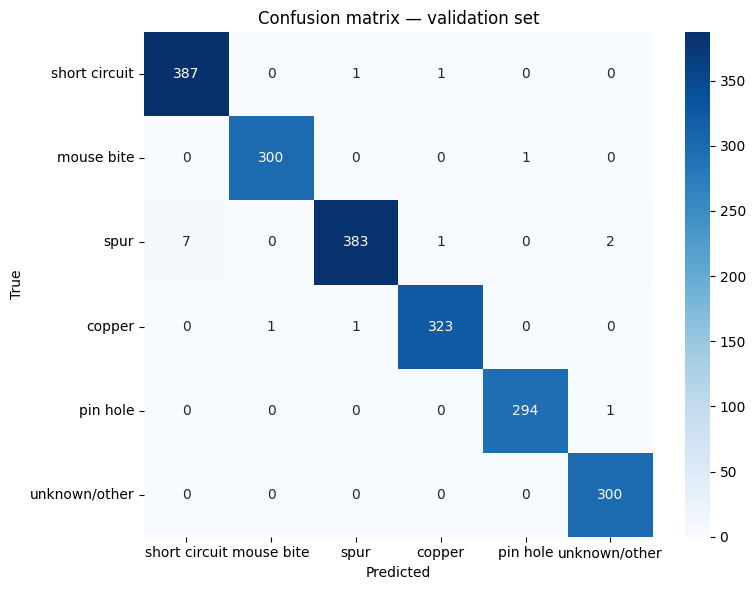


Classification report:
               precision    recall  f1-score   support

short circuit       0.98      0.99      0.99       389
   mouse bite       1.00      1.00      1.00       301
         spur       0.99      0.97      0.98       393
       copper       0.99      0.99      0.99       325
     pin hole       1.00      1.00      1.00       295
unknown/other       0.99      1.00      1.00       300

     accuracy                           0.99      2003
    macro avg       0.99      0.99      0.99      2003
 weighted avg       0.99      0.99      0.99      2003



In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = [defect_names[i] for i in range(6)]
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix — validation set')
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

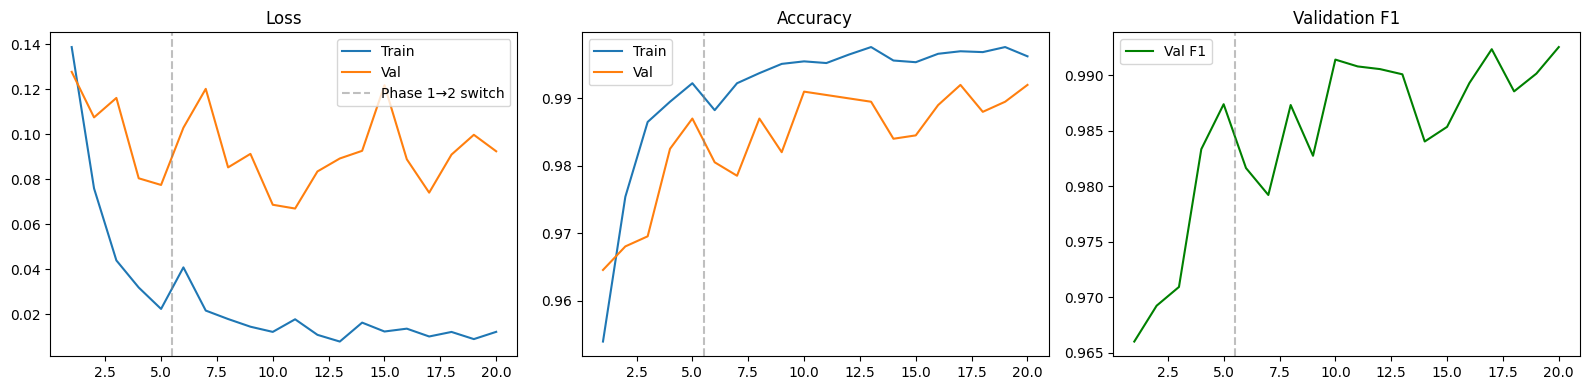

In [21]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2 switch')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Val')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy')
axes[1].legend()

axes[2].plot(epochs, history['val_f1'], label='Val F1', color='green')
axes[2].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Validation F1')
axes[2].legend()

plt.tight_layout()
plt.show()

In [22]:
train_df['source_image'] = train_df['crop_path'].apply(lambda p: os.path.basename(p).split('_label')[0])
val_df['source_image'] = val_df['crop_path'].apply(lambda p: os.path.basename(p).split('_label')[0])

overlap = set(train_df['source_image']).intersection(set(val_df['source_image']))
print(f"Overlapping source images between train and val: {len(overlap)}")
print(f"Train unique sources: {train_df['source_image'].nunique()}")
print(f"Val unique sources: {val_df['source_image'].nunique()}")

Overlapping source images between train and val: 0
Train unique sources: 8010
Val unique sources: 2003


In [24]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


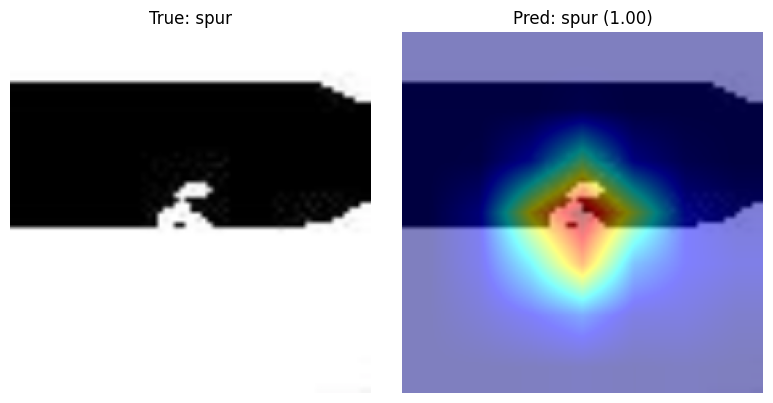

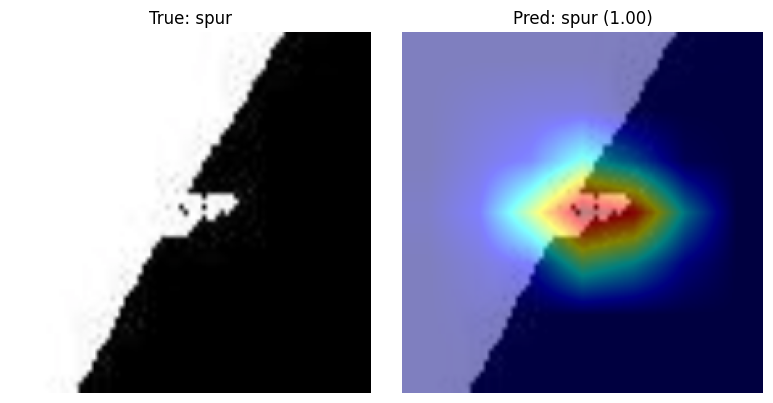

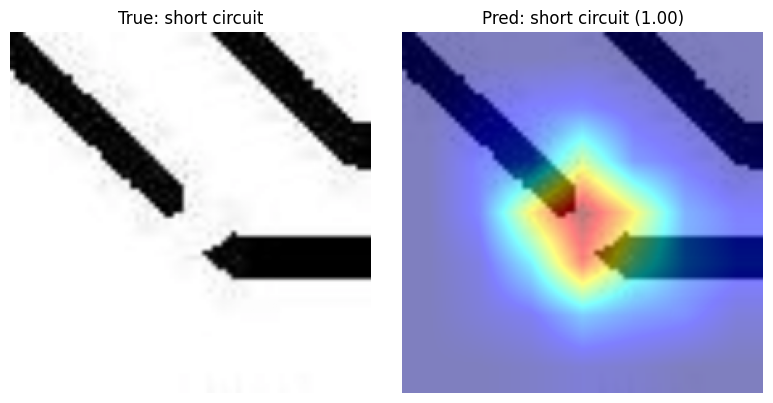

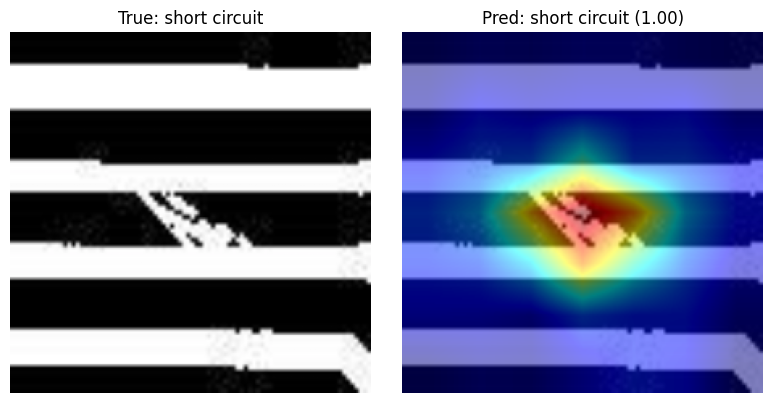

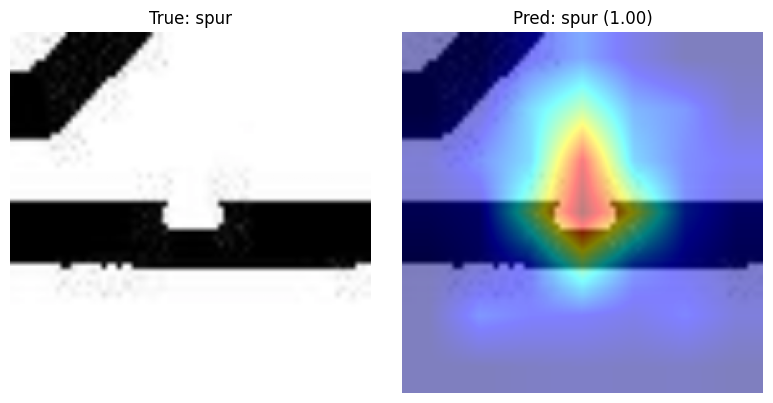

In [25]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn.functional as F

target_layer = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layer)

def unnormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img * std + mean

def show_gradcam(idx, dataset):
    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    img_unnorm = unnormalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    visualization = show_cam_on_image(img_unnorm, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()
        conf = F.softmax(output, dim=1)[0][pred].item()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_unnorm)
    axes[0].set_title(f'True: {defect_names[label]}')
    axes[0].axis('off')
    axes[1].imshow(visualization)
    axes[1].set_title(f'Pred: {defect_names[pred]} ({conf:.2f})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

for i in range(5):
    show_gradcam(i, val_dataset)

In [26]:
import json

history_path = os.path.join(LOGS_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

class_mapping = {str(k): v for k, v in defect_names.items()}
mapping_path = os.path.join(MODELS_DIR, 'class_mapping.json')
with open(mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("History saved:", os.path.exists(history_path))
print("Class mapping saved:", os.path.exists(mapping_path))
print("Best model saved:", os.path.exists(best_model_path))
print(f"Best val F1: {best_val_f1:.4f}")

History saved: True
Class mapping saved: True
Best model saved: True
Best val F1: 0.9925
